In [1]:
import subprocess, sys
for pkg in ['lightgbm','shap','lunardate']:
    subprocess.run([sys.executable,'-m','pip','install',pkg,'-q'], check=True)
print('Cài xong thư viện')

Cài xong thư viện


In [2]:
import numpy as np
import pandas as pd
import os, warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import shap
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

from lunardate import LunarDate

SEED = 42
np.random.seed(SEED)
print('Import xong')

Import xong


## 1. Load Data

In [ ]:

DATA_PATH = r"D:\Datathon2026_DataFusion4\data\processed"

sales             = pd.read_csv(os.path.join(DATA_PATH, 'sales.csv'),             parse_dates=['Date'])
sample_submission = pd.read_csv(os.path.join(DATA_PATH, 'sample_submission.csv'), parse_dates=['Date'])
web_traffic       = pd.read_csv(os.path.join(DATA_PATH, 'web_traffic.csv'),       parse_dates=['date'])
inventory         = pd.read_csv(os.path.join(DATA_PATH, 'inventory.csv'),         parse_dates=['snapshot_date'])

print(f'Sales train : {sales.shape} | {sales["Date"].min().date()} -> {sales["Date"].max().date()}')
print(f'Sample sub  : {sample_submission.shape} | {sample_submission["Date"].min().date()} -> {sample_submission["Date"].max().date()}')
print(f'Web traffic : {web_traffic.shape}')
print(f'Inventory   : {inventory.shape}')

Sales train : (3833, 3) | 2012-07-04 -> 2022-12-31
Sample sub  : (548, 3) | 2023-01-01 -> 2024-07-01
Web traffic : (3652, 7)
Inventory   : (60247, 17)


## 2. Chuẩn bị External Signals

In [4]:
# --- Web Traffic: tổng sessions mỗi ngày ---
web_daily = (
    web_traffic
    .groupby('date', as_index=False)['sessions']
    .sum()
    .rename(columns={'date': 'Date', 'sessions': 'daily_sessions'})
)

# --- Stockout: % SKU bị hết hàng mỗi tháng → map xuống ngày ---
stockout_monthly = (
    inventory
    .groupby('snapshot_date', as_index=False)['stockout_flag']
    .mean()
    .rename(columns={'snapshot_date': 'Date', 'stockout_flag': 'stockout_rate'})
)
# Inventory là monthly snapshot → forward-fill xuống daily
all_dates = pd.date_range(sales['Date'].min(), sample_submission['Date'].max(), freq='D')
stockout_daily = (
    pd.DataFrame({'Date': all_dates})
    .merge(stockout_monthly, on='Date', how='left')
    .sort_values('Date')
)
stockout_daily['stockout_rate'] = stockout_daily['stockout_rate'].ffill().fillna(0)

print('Web traffic daily:', web_daily.shape)
print('Stockout daily   :', stockout_daily.shape)
print(web_daily.head(3))

Web traffic daily: (3652, 2)
Stockout daily   : (4381, 2)
        Date  daily_sessions
0 2013-01-01            9760
1 2013-01-02           10456
2 2013-01-03           10076


## 3. Tạo Tet Map & Event Calendar

In [5]:
# Ngày Tết Nguyên Đán 2012-2026
tet_map = {}
for year in range(2012, 2027):
    tet_map[year] = pd.Timestamp(LunarDate(year, 1, 1).toSolarDate())

# Mega Sale events (tháng, ngày)
MEGA_SALE_DAYS = {(9,9), (10,10), (11,11), (12,12)}

# Tất cả ngày mega sale trong lịch sử + test range
mega_dates = sorted([
    pd.Timestamp(year=y, month=m, day=d)
    for y in range(2012, 2026)
    for m, d in MEGA_SALE_DAYS
])

print('Tet dates (5 gần nhất):')
for y, d in list(tet_map.items())[-5:]:
    print(f'  {y}: {d.date()}')

print('Mega sale dates (5 gần nhất):')
for d in mega_dates[-5:]:
    print(f'  {d.date()}')

Tet dates (5 gần nhất):
  2022: 2022-02-01
  2023: 2023-01-22
  2024: 2024-02-10
  2025: 2025-01-29
  2026: 2026-02-17
Mega sale dates (5 gần nhất):
  2024-12-12
  2025-09-09
  2025-10-10
  2025-11-11
  2025-12-12


## 4. Feature Engineering


In [6]:
def days_to_next_event(date, event_list):
    """Số ngày còn lại đến sự kiện kế tiếp trong event_list."""
    future = [e for e in event_list if e >= date]
    if not future:
        return 999
    return (future[0] - date).days


def build_features(df, target_col='log_revenue', cogs_col='log_cogs'):
    """
    Build features trên log scale.
    Input df phải có cột: Date, log_revenue (có thể NaN cho test), log_cogs
    """
    df = df.sort_values('Date').reset_index(drop=True)

    # ── 1. Time features ─────────────────────────────────────────────
    df['month']      = df['Date'].dt.month
    df['day']        = df['Date'].dt.day
    df['dayofweek']  = df['Date'].dt.dayofweek
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['quarter']    = df['Date'].dt.quarter
    df['dayofyear']  = df['Date'].dt.dayofyear

    # ── 2. Tết features ──────────────────────────────────────────────
    df['tet_date']    = df['Date'].dt.year.map(tet_map)
    df['days_to_tet'] = (df['Date'] - df['tet_date']).dt.days
    df['is_pre_tet']  = df['days_to_tet'].between(-20, -1).astype(int)
    df['is_tet']      = df['days_to_tet'].between(0, 7).astype(int)
    df['is_post_tet'] = df['days_to_tet'].between(8, 22).astype(int)
    df.drop(columns=['tet_date'], inplace=True)

    # ── 3. Mega sale flags ───────────────────────────────────────────
    month_day = list(zip(df['month'], df['day']))
    df['is_mega_sale'] = [1 if md in MEGA_SALE_DAYS else 0 for md in month_day]
    df['is_1111']      = ((df['month'] == 11) & (df['day'] == 11)).astype(int)
    df['is_1212']      = ((df['month'] == 12) & (df['day'] == 12)).astype(int)

    # ── 4. Countdown features — CỐT LÕI để phá vòng lặp đóng băng ──
    # FIX LỖI 2: Model biết trước sự kiện → không bị 'nhịn' mãi mãi
    df['days_to_next_mega'] = df['Date'].apply(
        lambda d: days_to_next_event(d, mega_dates)
    )
    tet_dates_list = sorted(tet_map.values())
    df['days_to_next_tet'] = df['Date'].apply(
        lambda d: days_to_next_event(d, tet_dates_list)
    )
    # Clip để tránh giá trị quá lớn làm nhiễu
    df['days_to_next_mega'] = df['days_to_next_mega'].clip(0, 90)
    df['days_to_next_tet']  = df['days_to_next_tet'].clip(0, 90)

    # ── 5. Lag features trên LOG SCALE — FIX LỖI 1 ──────────────────
    # Log scale: doanh thu bùng spike → log tăng tuyến tính → model nắm được
    for lag in [1, 7, 14, 30, 365]:
        df[f'rev_lag_{lag}'] = df[target_col].shift(lag)

    # ── 6. Rolling trên log scale ────────────────────────────────────
    df['rev_roll_mean_7']  = df[target_col].shift(1).rolling(7).mean()
    df['rev_roll_mean_30'] = df[target_col].shift(1).rolling(30).mean()
    df['rev_roll_std_7']   = df[target_col].shift(1).rolling(7).std()
    df['rev_trend']        = df['rev_roll_mean_7'] - df['rev_roll_mean_30']

    # ── 7. COGS ratio feature ─────────────────────────────────────────
    if cogs_col in df.columns:
        for lag in [1, 7]:
            df[f'cogs_lag_{lag}'] = df[cogs_col].shift(lag)

    return df


print('build_features() đã định nghĩa')

build_features() đã định nghĩa


## 5. Build Training Dataset


In [7]:
# Ghép web traffic & stockout vào sales
df_full = (
    sales
    .merge(web_daily,      on='Date', how='left')
    .merge(stockout_daily, on='Date', how='left')
)

# Fill NaN external signals
df_full['daily_sessions'] = df_full['daily_sessions'].fillna(df_full['daily_sessions'].median())
df_full['stockout_rate']  = df_full['stockout_rate'].fillna(0)

# ── FIX LỖI 1: Log transform target TRƯỚC KHI tạo features ──────────────────
# log1p(x) = log(1+x): an toàn khi x=0, giữ tỉ lệ spike đúng
df_full['log_revenue'] = np.log1p(df_full['Revenue'])
df_full['log_cogs']    = np.log1p(df_full['COGS'])

# Build features trên log scale
df_full = build_features(df_full, target_col='log_revenue', cogs_col='log_cogs')

print(f'Shape: {df_full.shape}')
print(f'Date range: {df_full["Date"].min().date()} -> {df_full["Date"].max().date()}')
null_feat = df_full.isnull().sum()
print('Null counts (top 10):')
print(null_feat[null_feat > 0].head(10))

Shape: (3833, 33)
Date range: 2012-07-04 -> 2022-12-31
Null counts (top 10):
rev_lag_1             1
rev_lag_7             7
rev_lag_14           14
rev_lag_30           30
rev_lag_365         365
rev_roll_mean_7       7
rev_roll_mean_30     30
rev_roll_std_7        7
rev_trend            30
cogs_lag_1            1
dtype: int64


In [8]:
# Các cột không dùng làm feature
EXCLUDE_COLS = {'Date', 'Revenue', 'COGS', 'log_revenue', 'log_cogs'}

FEATURE_COLS = [c for c in df_full.columns if c not in EXCLUDE_COLS]
print(f'Tổng số features: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

Tổng số features: 28
['daily_sessions', 'stockout_rate', 'month', 'day', 'dayofweek', 'is_weekend', 'quarter', 'dayofyear', 'days_to_tet', 'is_pre_tet', 'is_tet', 'is_post_tet', 'is_mega_sale', 'is_1111', 'is_1212', 'days_to_next_mega', 'days_to_next_tet', 'rev_lag_1', 'rev_lag_7', 'rev_lag_14', 'rev_lag_30', 'rev_lag_365', 'rev_roll_mean_7', 'rev_roll_mean_30', 'rev_roll_std_7', 'rev_trend', 'cogs_lag_1', 'cogs_lag_7']


## 6. TimeSeriesSplit Training — Walk-forward Validation


In [9]:
# Chỉ train trên dữ liệu không có NaN lag (bỏ 365 ngày đầu)
df_train = df_full.dropna(subset=FEATURE_COLS).copy()
print(f'Train rows: {len(df_train)} | {df_train["Date"].min().date()} -> {df_train["Date"].max().date()}')

X        = df_train[FEATURE_COLS].values
y_log_rev  = df_train['log_revenue'].values   # TARGET: log scale
y_log_cogs = df_train['log_cogs'].values      # TARGET: log scale

# ── LightGBM params ──────────────────────────────────────────────────────────
# alpha=0.5 → L1 thuần túy để bắt median tốt hơn với log-transformed data
# alpha=0.9 gây bias nặng → median hằng số — ĐÃ BỎ
BASE_PARAMS = {
    'objective':         'huber',
    'alpha':             0.5,      # FIX: 0.9 → 0.5 — cân bằng hơn
    'n_estimators':      2000,     # cao, để early stopping quyết định
    'learning_rate':     0.03,
    'num_leaves':        63,
    'max_depth':         -1,
    'min_child_samples': 20,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'reg_alpha':         0.1,
    'reg_lambda':        1.0,
    'random_state':      SEED,
    'n_jobs':            -1,
    'verbose':           -1,
}

# ── Walk-forward CV ──────────────────────────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=5)
cv_scores_rev  = {'mae':[], 'rmse':[], 'r2':[]}
cv_scores_cogs = {'mae':[], 'rmse':[], 'r2':[]}

# FIX LỖI 3: Lưu best_iteration từ mỗi fold
best_iters_rev  = []
best_iters_cogs = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_val   = X[train_idx], X[val_idx]
    yr_tr, yr_val = y_log_rev[train_idx],  y_log_rev[val_idx]
    yc_tr, yc_val = y_log_cogs[train_idx], y_log_cogs[val_idx]

    # Revenue model với early stopping
    model_rev = lgb.LGBMRegressor(**BASE_PARAMS)
    model_rev.fit(
        X_tr, yr_tr,
        eval_set=[(X_val, yr_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(-1)
        ]
    )
    best_iters_rev.append(model_rev.best_iteration_)

    # COGS model với early stopping
    model_cogs = lgb.LGBMRegressor(**BASE_PARAMS)
    model_cogs.fit(
        X_tr, yc_tr,
        eval_set=[(X_val, yc_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(-1)
        ]
    )
    best_iters_cogs.append(model_cogs.best_iteration_)

    # Metrics trên scale gốc (expm1 để so sánh với business)
    pred_rev_log  = model_rev.predict(X_val)
    pred_rev_orig = np.expm1(pred_rev_log)
    yr_val_orig   = np.expm1(yr_val)

    mae_r  = mean_absolute_error(yr_val_orig, pred_rev_orig)
    rmse_r = np.sqrt(mean_squared_error(yr_val_orig, pred_rev_orig))
    r2_r   = r2_score(yr_val_orig, pred_rev_orig)
    cv_scores_rev['mae'].append(mae_r)
    cv_scores_rev['rmse'].append(rmse_r)
    cv_scores_rev['r2'].append(r2_r)

    pred_cogs_orig = np.expm1(model_cogs.predict(X_val))
    yc_val_orig    = np.expm1(yc_val)
    mae_c  = mean_absolute_error(yc_val_orig, pred_cogs_orig)
    rmse_c = np.sqrt(mean_squared_error(yc_val_orig, pred_cogs_orig))
    r2_c   = r2_score(yc_val_orig, pred_cogs_orig)
    cv_scores_cogs['mae'].append(mae_c)
    cv_scores_cogs['rmse'].append(rmse_c)
    cv_scores_cogs['r2'].append(r2_c)

    print(f'Fold {fold+1} | Rev  MAE={mae_r:,.0f}  RMSE={rmse_r:,.0f}  R2={r2_r:.4f}  best_iter={model_rev.best_iteration_}')
    print(f'       | COGS MAE={mae_c:,.0f}  RMSE={rmse_c:,.0f}  R2={r2_c:.4f}  best_iter={model_cogs.best_iteration_}')

print('\n=== CV Summary ===')
print(f'Revenue  MAE : {np.mean(cv_scores_rev["mae"]):,.0f} ± {np.std(cv_scores_rev["mae"]):,.0f}')
print(f'Revenue  RMSE: {np.mean(cv_scores_rev["rmse"]):,.0f} ± {np.std(cv_scores_rev["rmse"]):,.0f}')
print(f'Revenue  R²  : {np.mean(cv_scores_rev["r2"]):.4f} ± {np.std(cv_scores_rev["r2"]):.4f}')
print(f'COGS     MAE : {np.mean(cv_scores_cogs["mae"]):,.0f}')
print(f'COGS     R²  : {np.mean(cv_scores_cogs["r2"]):.4f}')

# FIX LỖI 3: Tính best_iteration trung bình
best_n_rev  = max(int(np.mean(best_iters_rev)),  50)
best_n_cogs = max(int(np.mean(best_iters_cogs)), 50)
print(f'\nbest_n_rev  = {best_n_rev}  (từ {best_iters_rev})')
print(f'best_n_cogs = {best_n_cogs}  (từ {best_iters_cogs})')

Train rows: 3468 | 2013-07-04 -> 2022-12-31
Fold 1 | Rev  MAE=998,671  RMSE=1,508,568  R2=0.7454  best_iter=178
       | COGS MAE=840,563  RMSE=1,263,105  R2=0.7411  best_iter=170
Fold 2 | Rev  MAE=733,994  RMSE=1,025,142  R2=0.8597  best_iter=381
       | COGS MAE=649,863  RMSE=893,645  R2=0.8614  best_iter=461
Fold 3 | Rev  MAE=804,723  RMSE=1,087,003  R2=0.8480  best_iter=300
       | COGS MAE=756,573  RMSE=989,247  R2=0.8102  best_iter=260
Fold 4 | Rev  MAE=544,274  RMSE=770,749  R2=0.8014  best_iter=216
       | COGS MAE=456,919  RMSE=648,525  R2=0.8016  best_iter=211
Fold 5 | Rev  MAE=537,243  RMSE=739,946  R2=0.7746  best_iter=291
       | COGS MAE=491,272  RMSE=696,328  R2=0.7406  best_iter=117

=== CV Summary ===
Revenue  MAE : 723,781 ± 172,765
Revenue  RMSE: 1,026,281 ± 276,974
Revenue  R²  : 0.8058 ± 0.0432
COGS     MAE : 639,038
COGS     R²  : 0.7910

best_n_rev  = 273  (từ [178, 381, 300, 216, 291])
best_n_cogs = 243  (từ [170, 461, 260, 211, 117])


## 7. Retrain trên Toàn bộ Training Data


In [10]:
# FIX: dùng best_n thay vì n_estimators=1500 không có eval_set
params_final_rev  = {**BASE_PARAMS, 'n_estimators': best_n_rev}
params_final_cogs = {**BASE_PARAMS, 'n_estimators': best_n_cogs}

final_model_rev  = lgb.LGBMRegressor(**params_final_rev)
final_model_cogs = lgb.LGBMRegressor(**params_final_cogs)

final_model_rev.fit(X, y_log_rev)
final_model_cogs.fit(X, y_log_cogs)

print('Retrain xong!')
print(f'n_estimators Rev : {final_model_rev.n_estimators}')
print(f'n_estimators COGS: {final_model_cogs.n_estimators}')

Retrain xong!
n_estimators Rev : 273
n_estimators COGS: 243


## 8. Dự báo Tập Test (Recursive Forecast)


In [11]:
# Ghép test dates với external signals
test_ext = (
    sample_submission[['Date']].copy()
    .merge(web_daily,      on='Date', how='left')
    .merge(stockout_daily, on='Date', how='left')
)
test_ext['daily_sessions'] = test_ext['daily_sessions'].fillna(df_full['daily_sessions'].median())
test_ext['stockout_rate']  = test_ext['stockout_rate'].fillna(0)

# Lịch sử trên LOG SCALE để lookup lag
history = df_full[['Date', 'log_revenue', 'log_cogs']].set_index('Date')

predictions = []

for _, row in test_ext.iterrows():
    date = row['Date']

    # Gắn external signals cho ngày hiện tại
    row_data = {
        'Date':           date,
        'log_revenue':    np.nan,   # placeholder — sẽ được điền sau dự báo
        'log_cogs':       np.nan,
        'daily_sessions': row['daily_sessions'],
        'stockout_rate':  row['stockout_rate'],
    }

    tmp_df = pd.concat(
        [history.reset_index(), pd.DataFrame([row_data])],
        ignore_index=True
    ).sort_values('Date').reset_index(drop=True)

    # Build features — bao gồm days_to_next_mega, days_to_next_tet
    tmp_df = build_features(tmp_df, target_col='log_revenue', cogs_col='log_cogs')

    feat_row = tmp_df.iloc[[-1]][FEATURE_COLS]

    # Dự báo trên log scale → convert về gốc bằng expm1
    pred_log_rev  = float(final_model_rev.predict(feat_row)[0])
    pred_log_cogs = float(final_model_cogs.predict(feat_row)[0])

    pred_rev  = max(float(np.expm1(pred_log_rev)),  0)
    pred_cogs = max(float(np.expm1(pred_log_cogs)), 0)
    pred_cogs = min(pred_cogs, pred_rev * 0.99)   # đảm bảo cogs <= revenue

    predictions.append({'Date': date, 'Revenue': pred_rev, 'COGS': pred_cogs})

    # Cập nhật history trên LOG SCALE để làm lag cho ngày kế tiếp
    new_row = pd.DataFrame([{
        'Date':        date,
        'log_revenue': pred_log_rev,
        'log_cogs':    pred_log_cogs
    }])
    history = pd.concat([history.reset_index(), new_row]).set_index('Date')

pred_df = pd.DataFrame(predictions)
print(f'Dự báo xong: {len(pred_df)} ngày')
print(pred_df.head())
print(f'Revenue range: {pred_df["Revenue"].min():,.0f} - {pred_df["Revenue"].max():,.0f}')
print(f'Số ngày Revenue > 1M: {(pred_df["Revenue"] > 1_000_000).sum()}')

Dự báo xong: 548 ngày
        Date       Revenue          COGS
0 2023-01-01  1.802674e+06  1.574050e+06
1 2023-01-02  1.414053e+06  1.104617e+06
2 2023-01-03  1.162948e+06  9.087048e+05
3 2023-01-04  1.164521e+06  8.621378e+05
4 2023-01-05  1.201349e+06  9.356892e+05
Revenue range: 767,387 - 9,484,271
Số ngày Revenue > 1M: 539


## 9. SHAP Explainability

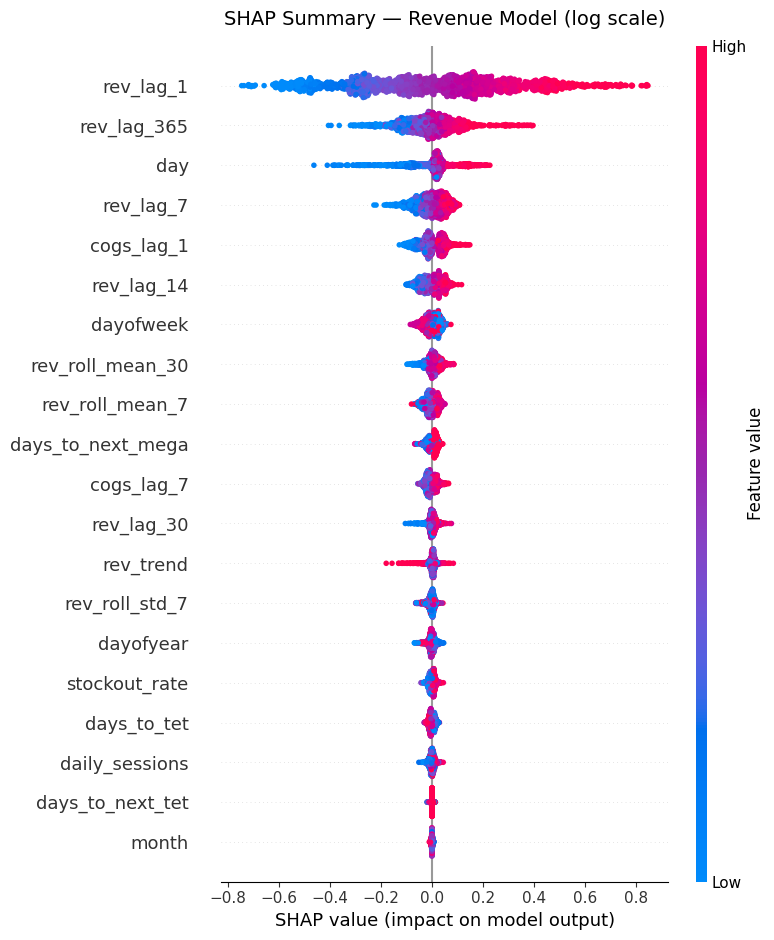

Đã lưu shap_summary.png


In [12]:
# Dùng TreeSHAP — nhanh với LightGBM
X_sample = df_train[FEATURE_COLS].sample(min(2000, len(df_train)), random_state=SEED)

explainer   = shap.TreeExplainer(final_model_rev)
shap_values = explainer.shap_values(X_sample)

# ── 9.1 Beeswarm Summary Plot ────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, feature_names=FEATURE_COLS,
                  max_display=20, show=False)
plt.title('SHAP Summary — Revenue Model (log scale)', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Đã lưu shap_summary.png')

Top 15 features quan trọng nhất:
          Feature  SHAP_mean
        rev_lag_1   0.261409
      rev_lag_365   0.077726
              day   0.061149
        rev_lag_7   0.042841
       cogs_lag_1   0.037517
       rev_lag_14   0.032637
        dayofweek   0.022222
 rev_roll_mean_30   0.019988
  rev_roll_mean_7   0.018316
days_to_next_mega   0.015270
       cogs_lag_7   0.015005
       rev_lag_30   0.010348
        rev_trend   0.010134
   rev_roll_std_7   0.009345
        dayofyear   0.009343


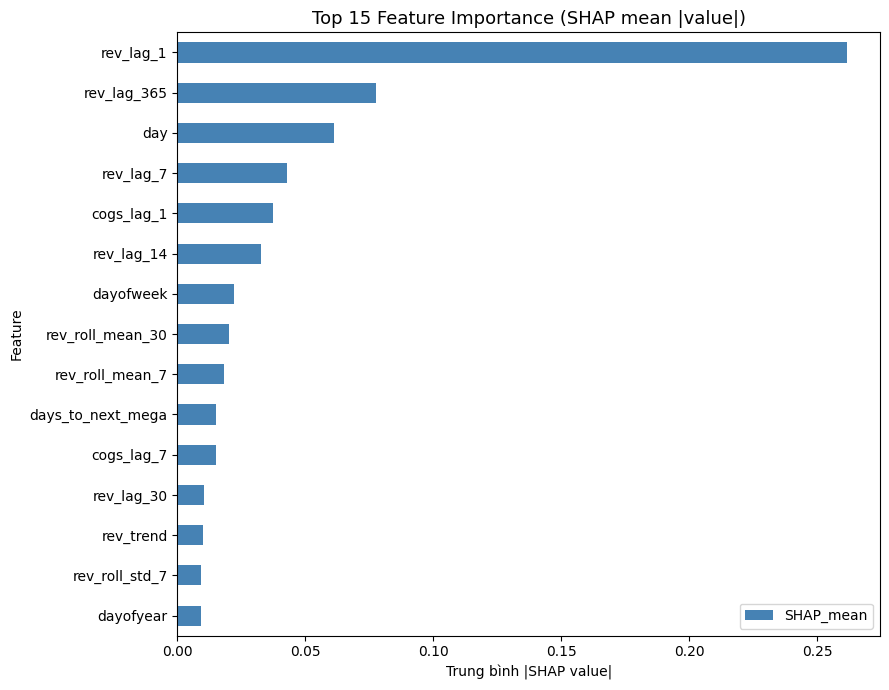

Đã lưu shap_bar.png


In [13]:
# ── 9.2 Feature Importance Bar Plot ─────────────────────────────────────────
shap_abs_mean = np.abs(shap_values).mean(axis=0)
feat_imp = pd.DataFrame({
    'Feature':   FEATURE_COLS,
    'SHAP_mean': shap_abs_mean,
}).sort_values('SHAP_mean', ascending=False)

print('Top 15 features quan trọng nhất:')
print(feat_imp.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 7))
feat_imp.head(15).plot.barh(x='Feature', y='SHAP_mean', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Top 15 Feature Importance (SHAP mean |value|)', fontsize=13)
ax.set_xlabel('Trung bình |SHAP value|')
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Đã lưu shap_bar.png')

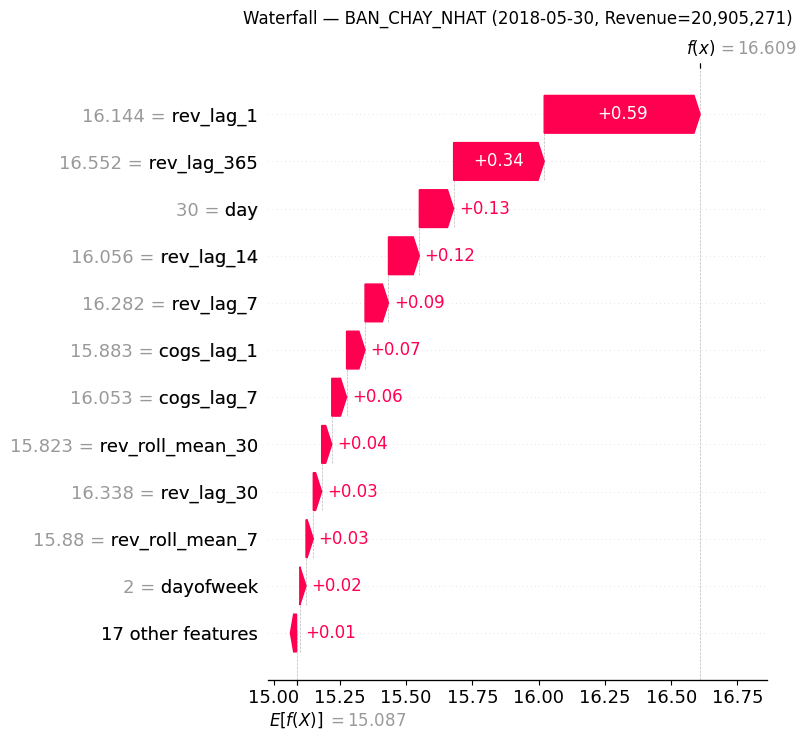

Đã lưu shap_waterfall_ban_chay_nhat.png


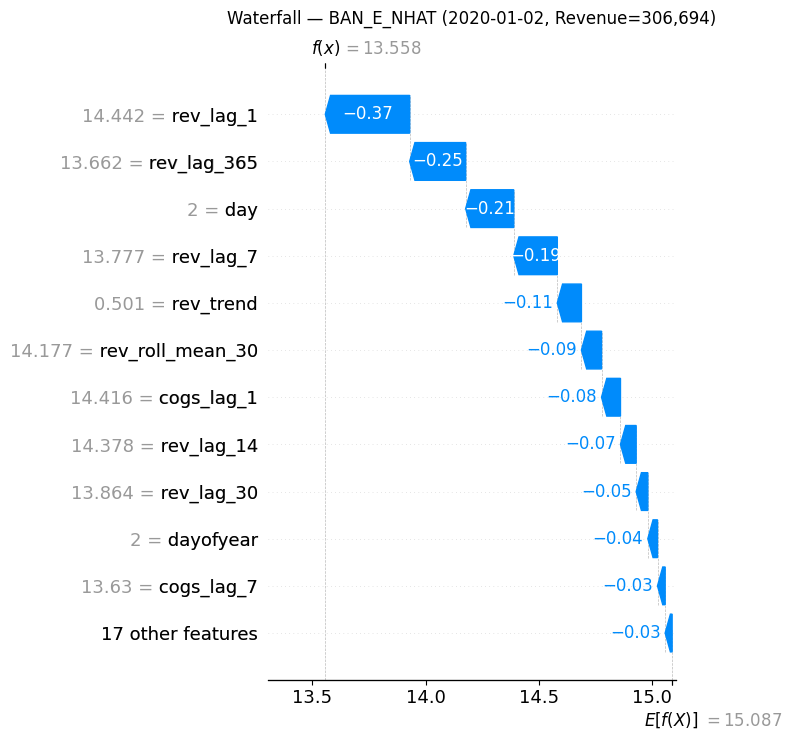

Đã lưu shap_waterfall_ban_e_nhat.png


In [14]:
# ── 9.3 Waterfall — ngày bán chạy nhất và ế nhất ────────────────────────────
best_idx  = df_train['log_revenue'].idxmax()
worst_idx = df_train['log_revenue'].idxmin()

for label, idx in [('BAN_CHAY_NHAT', best_idx), ('BAN_E_NHAT', worst_idx)]:
    row_date = df_train.loc[idx, 'Date']
    row_rev  = np.expm1(df_train.loc[idx, 'log_revenue'])
    feat_row = df_train.loc[[idx], FEATURE_COLS]
    sv = explainer(feat_row)

    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(sv[0], max_display=12, show=False)
    plt.title(f'Waterfall — {label} ({row_date.date()}, Revenue={row_rev:,.0f})', fontsize=12, pad=10)
    plt.tight_layout()
    fname = f'shap_waterfall_{label.lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Đã lưu {fname}')

## 10. Plot Thực tế vs Dự báo (Validation fold cuối)

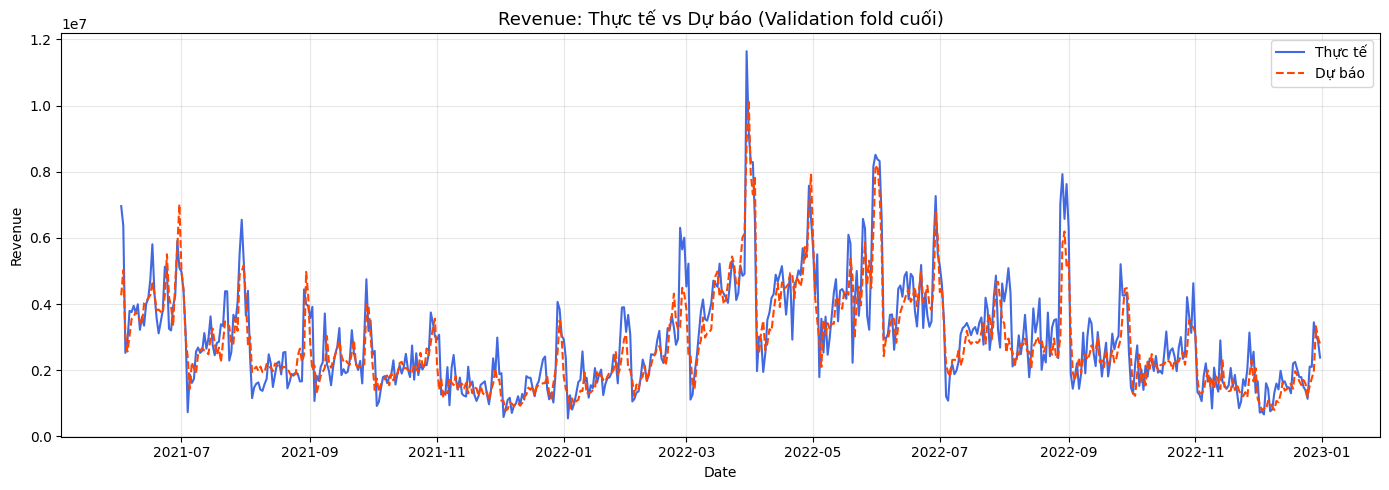

Fold cuối  |  MAE=537,734  RMSE=740,774  R²=0.7741


In [15]:
splits = list(tscv.split(X))
tr_idx, val_idx = splits[-1]

tmp_params = {**BASE_PARAMS, 'n_estimators': best_n_rev}
tmp_model  = lgb.LGBMRegressor(**tmp_params)
tmp_model.fit(X[tr_idx], y_log_rev[tr_idx], callbacks=[lgb.log_evaluation(-1)])

# Dự báo và convert về scale gốc
y_pred_log  = tmp_model.predict(X[val_idx])
y_pred_plot = np.expm1(y_pred_log)
y_val_plot  = np.expm1(y_log_rev[val_idx])
val_dates   = df_train.iloc[val_idx]['Date']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(val_dates.values, y_val_plot,  label='Thực tế', color='royalblue',  linewidth=1.5)
ax.plot(val_dates.values, y_pred_plot, label='Dự báo',  color='orangered',  linewidth=1.5, linestyle='--')
ax.set_title('Revenue: Thực tế vs Dự báo (Validation fold cuối)', fontsize=13)
ax.set_xlabel('Date'); ax.set_ylabel('Revenue')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('val_plot.png', dpi=150, bbox_inches='tight')
plt.show()

mae_f  = mean_absolute_error(y_val_plot, y_pred_plot)
rmse_f = np.sqrt(mean_squared_error(y_val_plot, y_pred_plot))
r2_f   = r2_score(y_val_plot, y_pred_plot)
print(f'Fold cuối  |  MAE={mae_f:,.0f}  RMSE={rmse_f:,.0f}  R²={r2_f:.4f}')

## 11. Tạo submission.csv

In [16]:
# Giữ đúng thứ tự ngày của sample_submission — KHÔNG sort lại
submission = sample_submission[['Date']].merge(pred_df, on='Date', how='left')

# Kiểm tra không thiếu dòng
assert len(submission) == len(sample_submission), 'Số dòng không khớp!'
assert submission['Revenue'].isna().sum() == 0, 'Có ngày bị thiếu Revenue!'
assert submission['COGS'].isna().sum()    == 0, 'Có ngày bị thiếu COGS!'

# Format đúng kiểu ngày như sample
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission = submission[['Date', 'Revenue', 'COGS']]

submission.to_csv('submission.csv', index=False)

print('=== submission.csv đã lưu ===')
print(f'Số dòng: {len(submission)}')
print(submission.head(5).to_string(index=False))
print('...')
print(submission.tail(3).to_string(index=False))

print(f'\nRevenue min/max: {submission["Revenue"].min():,.0f} / {submission["Revenue"].max():,.0f}')
print(f'COGS    min/max: {submission["COGS"].min():,.0f}    / {submission["COGS"].max():,.0f}')

=== submission.csv đã lưu ===
Số dòng: 548
      Date      Revenue         COGS
2023-01-01 1.802674e+06 1.574050e+06
2023-01-02 1.414053e+06 1.104617e+06
2023-01-03 1.162948e+06 9.087048e+05
2023-01-04 1.164521e+06 8.621378e+05
2023-01-05 1.201349e+06 9.356892e+05
...
      Date      Revenue         COGS
2024-06-29 5.354157e+06 4.736150e+06
2024-06-30 5.632365e+06 5.159901e+06
2024-07-01 5.032555e+06 3.967639e+06

Revenue min/max: 767,387 / 9,484,271
COGS    min/max: 755,092    / 8,698,199
